### Hybrid Model for Residential Water Consumption Category

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Multiply,
    Flatten, Lambda, RepeatVector, Permute
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define directory and load the data
dir_name = '/content/drive/MyDrive/THESIS/Data/Multivariate Data'
df = pd.read_csv(f"{dir_name}/[Raw]Multivariate_Data_Monthly.csv")
df.head()

Mounted at /content/drive


,Year,Month,Residential Monthly Average,Commercial Monthly Average,Government Monthly Average,RAINFALL,TMAX,TMIN,TMEAN,WIND_SPEED,WIND_DIRECTION,RH
0,2010,1,4940168.0,702499.0,156935.0,5.080645,30.564516,23.909677,27.258065,2.354839,213.225806,84.258065
1,2010,2,3996492.0,601294.0,137278.0,0.571429,32.521429,23.550000,28.053571,2.607143,176.071429,78.071429
2,2010,3,4423759.0,654733.0,145150.0,1.706452,33.493548,24.390323,28.954839,2.741935,159.354839,78.096774
3,2010,4,4605206.0,672214.0,141869.0,4.133333,32.516667,24.800000,28.680000,2.100000,245.666667,82.166667
4,2010,5,4475865.0,642270.0,137791.0,1.848387,32.822581,25.522581,29.193548,1.903226,164.516129,83.064516


In [3]:
# Normalize the `Residential Monthly Average`
scaler = MinMaxScaler()
df['Residential Monthly Average'] = scaler.fit_transform(df[['Residential Monthly Average']])

# Create input-output sequences for time series
time_steps = 12  # Use the past 12 months to predict the next month
X, y = [], []

for i in range(len(df) - time_steps):
    X.append(df['Residential Monthly Average'].values[i:i+time_steps])
    y.append(df['Residential Monthly Average'].values[i+time_steps])

X = np.array(X)
y = np.array(y)

# Reshape X to [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Attention block
def attention_block(inputs):
    # inputs: [batch_size, time_steps, lstm_units]
    attention_weights = Dense(1, activation='tanh')(inputs)  # Compute attention scores
    attention_weights = Flatten()(attention_weights)  # Flatten to 1D
    attention_weights = Dense(inputs.shape[1], activation='softmax')(attention_weights)  # Normalize over timesteps
    attention_weights = RepeatVector(inputs.shape[2])(attention_weights)  # Repeat for features
    attention_weights = Permute([2, 1])(attention_weights)  # Align dimensions for multiplication

    # Weighted sum of inputs
    weighted_inputs = Multiply()([inputs, attention_weights])
    return weighted_inputs

# Define the model architecture
input_layer = Input(shape=(time_steps, 1))

In [5]:
# Convolutional layers
conv1 = Conv1D(filters=16, kernel_size=3, activation='elu', padding='same')(input_layer)
conv2 = Conv1D(filters=32, kernel_size=3, activation='elu', padding='same')(conv1)
maxpool = MaxPooling1D(pool_size=2)(conv2)

# LSTM layers
lstm1 = LSTM(units=24, return_sequences=True)(maxpool)
lstm2 = LSTM(units=24, return_sequences=True)(lstm1)

# Attention mechanism
attention_output = attention_block(lstm2)
attention_output = Lambda(lambda x: tf.reduce_sum(x, axis=1))(attention_output)  # Summarize over time axis

# Fully connected layers
dense = Dense(units=64, activation='elu')(attention_output)
dropout = Dropout(rate=0.2)(dense)
output = Dense(units=1, activation='linear')(dropout)

# Compile the model
model = Model(inputs=input_layer, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 12, 1)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 12, 16)         │             64 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 12, 32)         │          1,568 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 6, 32)          │              0 │ conv1d_1[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 6, 24)          │          5,472 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 6, 24)          │          4,704 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 6, 1)           │             25 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 6)              │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 6)              │             42 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ repeat_vector             │ (None, 24, 6)          │              0 │ dense_1[0][0]          │
│ (RepeatVector)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ permute (Permute)         │ (None, 6, 24)          │              0 │ repeat_vector[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 6, 24)          │              0 │ lstm_1[0][0],          │
│                           │                        │                │ permute[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 24)             │              0 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │          1,600 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64)             │              0 │ dense_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 1)              │             65 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 13,540 (52.89 KB)

 Trainable params: 13,540 (52.89 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=16)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - loss: 0.2072 - mae: 0.4158 - val_loss: 0.1178 - val_mae: 0.3085
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0773 - mae: 0.2210 - val_loss: 0.0139 - val_mae: 0.0989
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0375 - mae: 0.1547 - val_loss: 0.0163 - val_mae: 0.1068
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0280 - mae: 0.1346 - val_loss: 0.0228 - val_mae: 0.1179
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0249 - mae: 0.1233 - val_loss: 0.0198 - val_mae: 0.1108
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0234 - mae: 0.1181 - val_loss: 0.0137 - val_mae: 0.0981
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0198 - mae: 0.1099 - val_loss: 0.0128 - val_mae: 0.0937
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0230 - mae: 0.1166 - val_loss: 0.0143 - val_mae: 0.0946
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0194 - mae: 0.1064 -

In [7]:
# Make predictions
y_pred = model.predict(X_test)

# Rescale predictions and true values back to the original scale
y_pred_rescaled = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate MAE, RMSE, and MAPE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Mean Absolute Error (MAE): 141574.77586206896
Root Mean Squared Error (RMSE): 181682.97960611508
Mean Absolute Percentage Error (MAPE): 3.003514967626309%


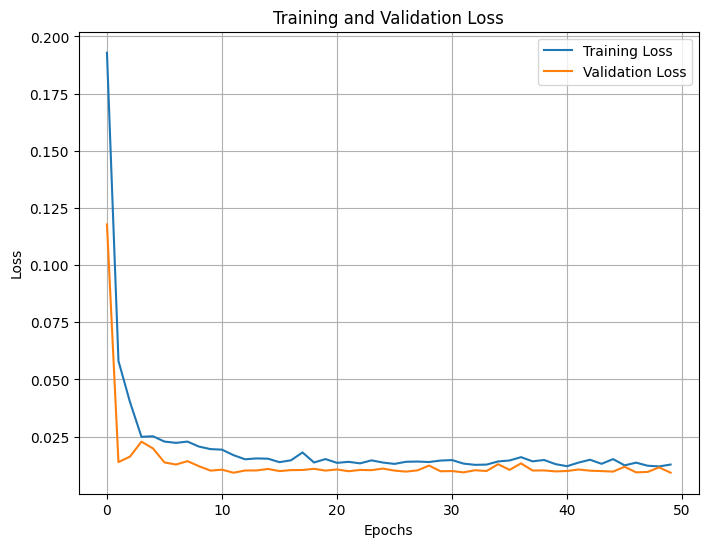

In [8]:
# Plotting training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

In [9]:
# Create a Date column using Year and Month
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))  # Assigning the first day of the month

# Extract dates corresponding to the test set
test_dates = df['Date'].iloc[-len(y_test):].values

# Create a DataFrame for predictions
results_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test_rescaled.flatten(),
    'Predicted': y_pred_rescaled.flatten()
})

# Define the output path
output_path = "/content/drive/MyDrive/THESIS/Codes/[Base] Hybrid Model wo Weather/Residential_Test_Predictions.csv"

# Export the DataFrame to a CSV file
results_df.to_csv(output_path, index=False)

print(f"Predictions have been saved to: {output_path}")

Predictions have been saved to: /content/drive/MyDrive/THESIS/Codes/[Base] Hybrid Model wo Weather/Residential_Test_Predictions.csv
